# Exploratory Data Analysis

This notebook explores the Olist e-commerce dataset stored in PostgreSQL.

The main goals are:
- to inspect the analytical data layer;
- to understand the structure and coverage of the data;
- to identify anomalies and important business patterns;
- to formulate hypotheses for further product analysis.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from etl.config import get_engine

engine = get_engine()

pd.read_sql(
    "SELECT current_database() AS database_name;",
    engine,
)

,database_name
0,olist_analytics


In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Analytical layer overview

In [3]:
query = """
SELECT table_name
FROM information_schema.views
WHERE table_schema = 'analytics'
ORDER BY table_name;
"""

analytics_views = pd.read_sql(query, engine)
analytics_views

,table_name
0,geolocation
1,order_items_enriched
2,order_metrics
3,orders_enriched
4,products


In [4]:
query = """
SELECT 'products' AS object_name, COUNT(*) AS row_count
FROM analytics.products

UNION ALL

SELECT 'geolocation', COUNT(*)
FROM analytics.geolocation

UNION ALL

SELECT 'orders_enriched', COUNT(*)
FROM analytics.orders_enriched

UNION ALL

SELECT 'order_items_enriched', COUNT(*)
FROM analytics.order_items_enriched

UNION ALL

SELECT 'order_metrics', COUNT(*)
FROM analytics.order_metrics

ORDER BY object_name;
"""

row_counts = pd.read_sql(query, engine)
row_counts

,object_name,row_count
0,geolocation,19015
1,order_items_enriched,112650
2,order_metrics,99441
3,orders_enriched,99441
4,products,32951


The analytical layer contains five views with different levels of granularity:

- one row per product;
- one row per ZIP code prefix;
- one row per order;
- one row per order item;
- one aggregated row per order.

## 2. Time coverage

In [5]:
query = """
SELECT
    MIN(order_purchase_timestamp) AS min_order_date,
    MAX(order_purchase_timestamp) AS max_order_date,
    COUNT(*) AS orders_count
FROM analytics.orders_enriched;
"""

time_coverage = pd.read_sql(query, engine)
time_coverage

,min_order_date,max_order_date,orders_count
0,2016-09-04 21:15:19,2018-10-17 17:30:18,99441


The dataset covers orders from the earliest to the latest purchase timestamp shown above.  
The boundary months should be checked separately because they may contain only partial data.

In [6]:
query = """
SELECT
    order_month,
    COUNT(*) AS orders_count
FROM analytics.orders_enriched
GROUP BY order_month
ORDER BY order_month;
"""

monthly_orders = pd.read_sql(query, engine)
monthly_orders.head()

,order_month,orders_count
0,2016-09-01,4
1,2016-10-01,324
2,2016-12-01,1
3,2017-01-01,800
4,2017-02-01,1780


In [7]:
monthly_orders.tail()

,order_month,orders_count
20,2018-06-01,6167
21,2018-07-01,6292
22,2018-08-01,6512
23,2018-09-01,16
24,2018-10-01,4


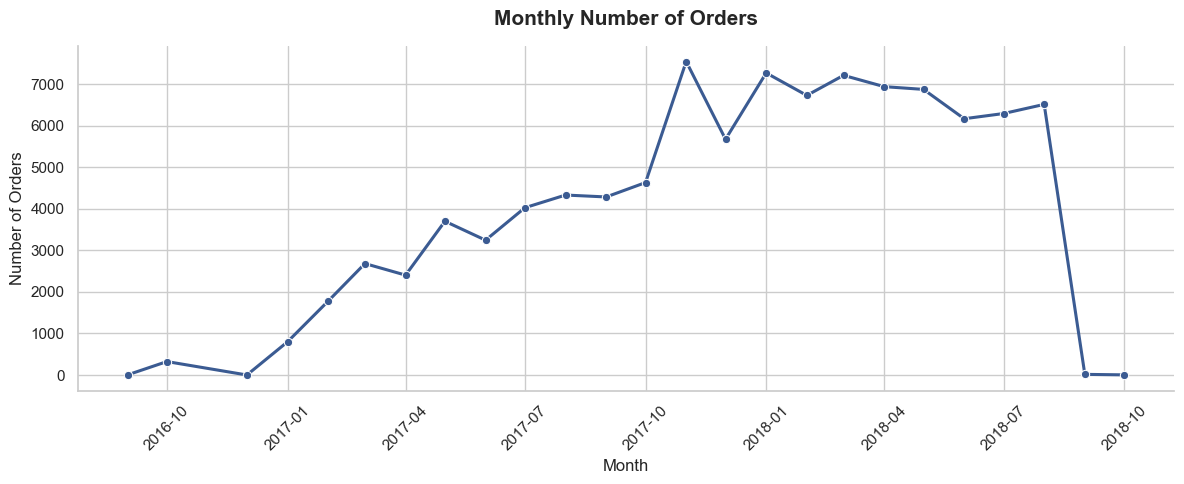

In [8]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_month",
    y="orders_count",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#3B5B92",
    ax=ax,
)

ax.set_title(
    "Monthly Number of Orders",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")

ax.tick_params(axis="x", rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

### Time coverage findings

The dataset covers the period from September 2016 to October 2018, but the boundary months are incomplete.

The number of orders was very low at the beginning of the observation period, so the 2016 data should not be compared directly with full months. From early 2017, the number of orders shows a clear upward trend, increasing from less than 1,000 orders per month to more than 4,000 by the second half of the year.

A noticeable peak appears in November 2017, when the monthly number of orders exceeds 7,000. This may be related to seasonal promotional activity, such as Black Friday, but this hypothesis requires additional verification.

During most of 2018, order volume remains relatively stable at approximately 6,000–7,000 orders per month. The sharp decline in September and October 2018 is caused by incomplete data coverage rather than an actual business decline.

Therefore, incomplete boundary months should be excluded from further monthly comparisons.

## 3. Order Status Analysis

In [9]:
query = """
SELECT
    order_status,
    COUNT(*) AS orders_count,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS share_percent
FROM analytics.orders_enriched
GROUP BY order_status
ORDER BY orders_count DESC;
"""

order_statuses = pd.read_sql(query, engine)
order_statuses

,order_status,orders_count,share_percent
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [10]:
query = """
SELECT
    EXTRACT(YEAR FROM order_purchase_timestamp)::INTEGER AS order_year,
    order_status,
    COUNT(*) AS orders_count
FROM analytics.orders_enriched
GROUP BY
    EXTRACT(YEAR FROM order_purchase_timestamp),
    order_status
ORDER BY
    order_year,
    orders_count DESC;
"""

statuses_by_year = pd.read_sql(query, engine)
statuses_by_year

,order_year,order_status,orders_count
0,2016,delivered,267
1,2016,canceled,26
2,2016,invoiced,18
3,2016,shipped,9
4,2016,unavailable,7
5,2016,processing,2
6,2017,delivered,43428
7,2017,shipped,530
8,2017,unavailable,457
9,2017,canceled,265


In [11]:
query = """
SELECT
    order_status,
    COUNT(*) AS orders_count,
    ROUND(SUM(order_items_value)::NUMERIC, 2) AS total_order_value,
    ROUND(AVG(order_items_value)::NUMERIC, 2) AS average_order_value
FROM analytics.order_metrics
GROUP BY order_status
ORDER BY total_order_value DESC NULLS LAST;
"""

status_value_summary = pd.read_sql(query, engine)
status_value_summary

,order_status,orders_count,total_order_value,average_order_value
0,delivered,96478,"15,419,773.75",159.83
1,shipped,1107,"177,129.34",160.15
2,canceled,625,"105,885.72",229.69
3,processing,301,"69,394.11",230.55
4,invoiced,314,"68,988.75",221.12
5,unavailable,609,"2,140.49",356.75
6,approved,2,241.08,120.54
7,created,5,NaN,NaN


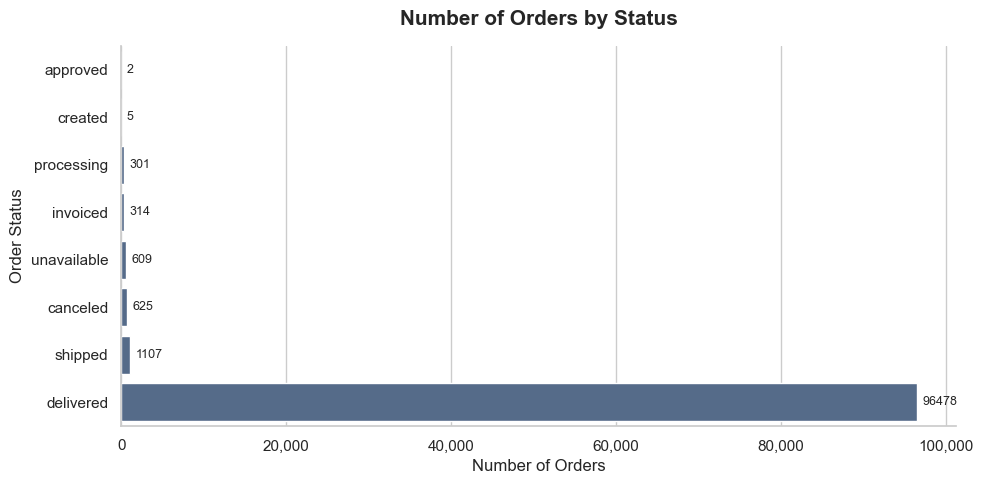

In [12]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 5))

plot_data = order_statuses.sort_values(
    "orders_count",
    ascending=True,
)

sns.barplot(
    data=plot_data,
    x="orders_count",
    y="order_status",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Number of Orders by Status",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Order Status")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{int(value):,}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Order status findings

Delivered orders dominate the dataset: 96,478 orders, or approximately 97% of all observations, have the `delivered` status.

The remaining statuses account for only a small share of the data. The largest groups among them are `shipped`, `canceled`, and `unavailable`. Orders with `created` or `approved` status are extremely rare.

The status distribution is consistent across the main observation period: delivered orders remain the dominant category in both 2017 and 2018. A small number of orders remain in intermediate statuses, which may be related to incomplete order lifecycles or the end of the data collection period.

For further revenue, delivery, review, retention, and customer behavior analysis, only delivered orders will be treated as completed transactions. Other statuses will be analyzed separately when studying cancellations or operational issues.

## 4. Missing values and incomplete orders

In [14]:
query = """
SELECT
    COUNT(*) AS total_orders,

    COUNT(*) FILTER (
        WHERE order_approved_at IS NULL
    ) AS missing_approved_at,

    COUNT(*) FILTER (
        WHERE order_delivered_carrier_date IS NULL
    ) AS missing_carrier_date,

    COUNT(*) FILTER (
        WHERE order_delivered_customer_date IS NULL
    ) AS missing_customer_date

FROM analytics.orders_enriched;
"""

missing_order_dates = pd.read_sql(query, engine)
missing_order_dates

,total_orders,missing_approved_at,missing_carrier_date,missing_customer_date
0,99441,160,1783,2965


In [15]:
query = """
SELECT
    COUNT(*) AS total_orders,

    COUNT(*) FILTER (
        WHERE payment_value IS NULL
    ) AS missing_payment_value,

    COUNT(*) FILTER (
        WHERE average_review_score IS NULL
    ) AS missing_review_score

FROM analytics.order_metrics;
"""

missing_related_data = pd.read_sql(query, engine)
missing_related_data

,total_orders,missing_payment_value,missing_review_score
0,99441,1,768


In [16]:
missing_summary = pd.concat(
    [
        missing_order_dates,
        missing_related_data.drop(columns="total_orders"),
    ],
    axis=1,
)

missing_summary

,total_orders,missing_approved_at,missing_carrier_date,missing_customer_date,missing_payment_value,missing_review_score
0,99441,160,1783,2965,1,768


In [17]:
missing_columns = [
    "missing_approved_at",
    "missing_carrier_date",
    "missing_customer_date",
    "missing_payment_value",
    "missing_review_score",
]

missing_rates = (
    missing_summary[missing_columns]
    .T
    .reset_index()
    .rename(
        columns={
            "index": "variable",
            0: "missing_count",
        }
    )
)

missing_rates

,variable,missing_count
0,missing_approved_at,160
1,missing_carrier_date,1783
2,missing_customer_date,2965
3,missing_payment_value,1
4,missing_review_score,768


In [18]:
missing_rates["missing_share_percent"] = (
    missing_rates["missing_count"]
    / missing_summary.loc[0, "total_orders"]
    * 100
)

missing_rates

,variable,missing_count,missing_share_percent
0,missing_approved_at,160,0.16
1,missing_carrier_date,1783,1.79
2,missing_customer_date,2965,2.98
3,missing_payment_value,1,0.00
4,missing_review_score,768,0.77


In [19]:
query = """
SELECT
    o.order_status,
    COUNT(*) AS orders_count,

    COUNT(*) FILTER (
        WHERE o.order_approved_at IS NULL
    ) AS missing_approved_at,

    COUNT(*) FILTER (
        WHERE o.order_delivered_carrier_date IS NULL
    ) AS missing_carrier_date,

    COUNT(*) FILTER (
        WHERE o.order_delivered_customer_date IS NULL
    ) AS missing_customer_date,

    COUNT(*) FILTER (
        WHERE m.payment_value IS NULL
    ) AS missing_payment_value,

    COUNT(*) FILTER (
        WHERE m.average_review_score IS NULL
    ) AS missing_review_score

FROM analytics.orders_enriched AS o
JOIN analytics.order_metrics AS m
    ON o.order_id = m.order_id

GROUP BY o.order_status
ORDER BY orders_count DESC;
"""

missing_by_status = pd.read_sql(query, engine)
missing_by_status

,order_status,orders_count,missing_approved_at,missing_carrier_date,missing_customer_date,missing_payment_value,missing_review_score
0,delivered,96478,14,2,8,1,646
1,shipped,1107,0,0,1107,0,75
2,canceled,625,141,550,619,0,20
3,unavailable,609,0,609,609,0,14
4,invoiced,314,0,314,314,0,5
5,processing,301,0,301,301,0,6
6,created,5,5,5,5,0,2
7,approved,2,0,2,2,0,0


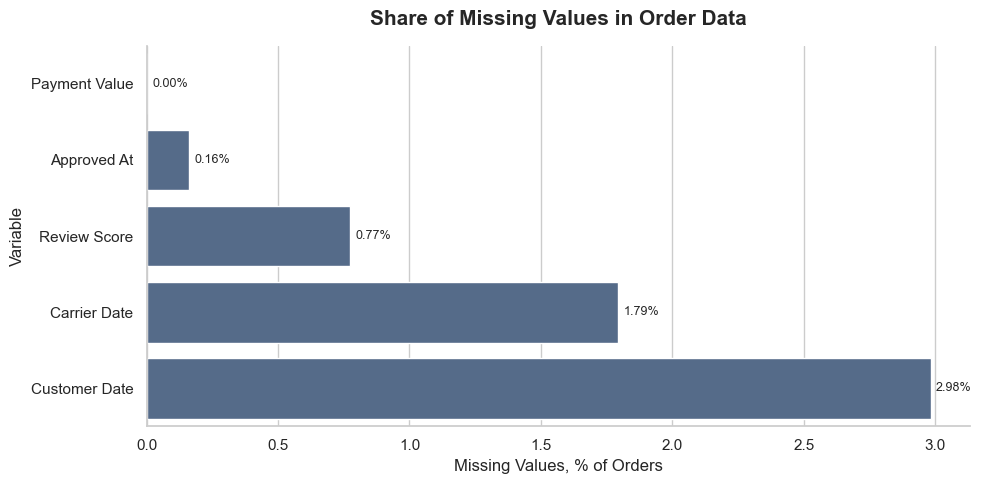

In [20]:
plot_data = (
    missing_rates
    .sort_values("missing_share_percent", ascending=True)
    .copy()
)

plot_data["variable"] = (
    plot_data["variable"]
    .str.replace("missing_", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=plot_data,
    x="missing_share_percent",
    y="variable",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Share of Missing Values in Order Data",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Missing Values, % of Orders")
ax.set_ylabel("Variable")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Missing value findings

The overall share of missing values is low across all analyzed fields.

The largest proportion of missing data is observed for the customer delivery date, at approximately 2.98% of orders. The carrier delivery date is missing for about 1.79% of orders. These fields describe later stages of the order lifecycle, so their absence is expected for canceled, unavailable, or otherwise incomplete orders.

Review scores are missing for less than 1% of orders, meaning that review data covers the vast majority of observations. The approval timestamp is missing in only 0.16% of cases, while missing payment values are negligible.

Overall, missing data does not appear to be a major data-quality issue. However, delivery-related analysis should be limited to orders with a recorded customer delivery date, and completed-transaction analysis should primarily use delivered orders.

## 5. Order Value Distribution

In [21]:
query = """
SELECT
    order_id,
    products_value,
    freight_value,
    order_items_value,
    payment_value,
    items_count
FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND order_items_value IS NOT NULL;
"""

order_values = pd.read_sql(query, engine)

order_values.head()

,order_id,products_value,freight_value,order_items_value,payment_value,items_count
0,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83,259.83,1
1,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87,216.87,1
2,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04,218.04,1
3,00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,34.59,34.59,1
4,00054e8431b9d7675808bcb819fb4a32,19.90,11.85,31.75,31.75,1


In [22]:
order_values[
    [
        "products_value",
        "freight_value",
        "order_items_value",
        "payment_value",
        "items_count",
    ]
].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

,products_value,freight_value,order_items_value,payment_value,items_count
count,"96,478.00","96,478.00","96,478.00","96,477.00","96,478.00"
mean,137.04,22.79,159.83,159.86,1.14
std,209.05,21.56,218.79,218.81,0.54
min,0.85,0.00,9.59,9.59,1.00
25%,45.90,13.85,61.85,61.88,1.00
50%,86.57,17.17,105.28,105.28,1.00
75%,149.90,24.02,176.26,176.33,1.00
90%,269.00,39.38,305.92,305.97,1.00
95%,399.00,54.78,446.23,446.31,2.00
99%,990.00,104.24,"1,052.39","1,052.39",3.00


In [24]:
order_values.sort_values("order_items_value", ascending=False).head(10)

,order_id,products_value,freight_value,order_items_value,payment_value,items_count
49051,03caa2c082116e1d31e67e9ae3700499,"13,440.00",224.08,"13,664.08","13,664.08",8
21762,736e1922ae60d0d6a89247b851902527,"7,160.00",114.88,"7,274.88","7,274.88",4
49874,0812eb902a67711a1cb742b3cdaa65ae,"6,735.00",194.31,"6,929.31","6,929.31",1
48146,fefacc66af859508bf1a7934eab1e97f,"6,729.00",193.21,"6,922.21","6,922.21",1
94459,f5136e38d1a14a4dbd87dff67da82701,"6,499.00",227.66,"6,726.66","6,726.66",1
8368,2cc9089445046817a7539d90805e6e5a,"5,934.60",146.94,"6,081.54","6,081.54",6
31908,a96610ab360d42a2e5335a3998b4718a,"4,799.00",151.34,"4,950.34","4,950.34",1
53162,199af31afc78c699f0dbf71fb178d4d4,"4,690.00",74.34,"4,764.34","4,764.34",1
74885,8dbc85d1447242f3b127dda390d56e19,"4,590.00",91.78,"4,681.78","4,681.78",1
60824,426a9742b533fc6fed17d1fd6d143d7e,"4,399.87",113.45,"4,513.32","4,513.32",1


In [25]:
order_value_99 = order_values["order_items_value"].quantile(0.99)

order_value_99

np.float64(1052.3898999999994)

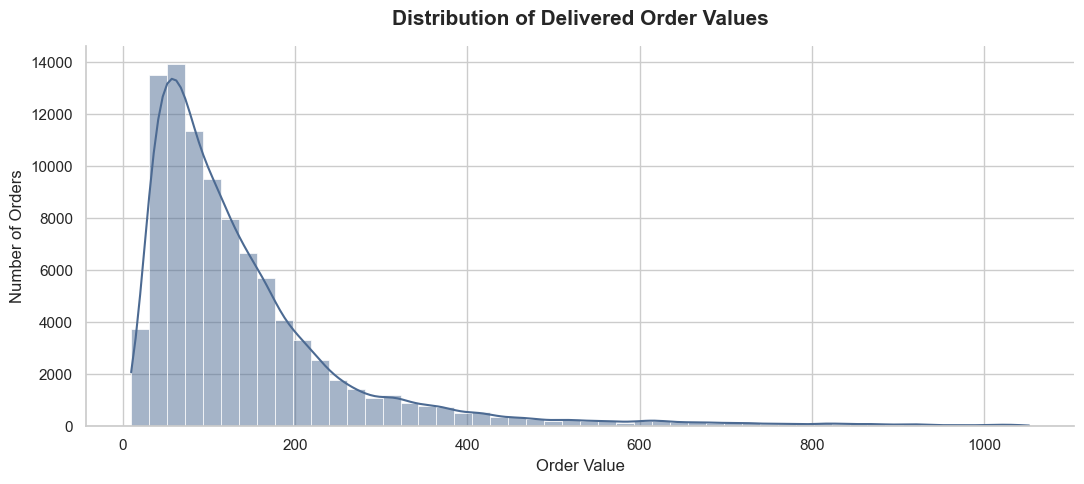

In [27]:
plot_data = order_values.loc[
    order_values["order_items_value"] <= order_value_99
].copy()

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(
    data=plot_data,
    x="order_items_value",
    bins=50,
    kde=True,
    color="#4C6A92",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_title(
    "Distribution of Delivered Order Values",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)

ax.set_xlabel("Order Value")
ax.set_ylabel("Number of Orders")

sns.despine()
plt.tight_layout()
plt.show()

### Order value findings

The distribution of delivered order values is strongly right-skewed.

Most orders are concentrated in the lower price range, while a relatively small number of expensive orders form a long right tail. This means that the mean order value is likely higher than the median and may be strongly influenced by high-value transactions.

The majority of delivered orders have a value below approximately 200, while orders above 500 are comparatively rare.

For further analysis, the median and percentiles should be considered alongside the average order value. The values above the 99th percentile were excluded only from the visualization and should not be removed from the dataset without additional evidence that they are erroneous.

In [ ]:
query = """
SELECT
    COUNT(*) AS delivered_orders,

    ROUND(
        AVG(delivery_time_days)::NUMERIC,
        2
    ) AS average_delivery_days,

    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY delivery_time_days
        )::NUMERIC,
        2
    ) AS median_delivery_days,

    ROUND(
        PERCENTILE_CONT(0.9) WITHIN GROUP (
            ORDER BY delivery_time_days
        )::NUMERIC,
        2
    ) AS delivery_days_90_percentile,

    COUNT(*) FILTER (
        WHERE is_delayed = TRUE
    ) AS delayed_orders,

    ROUND(
        100.0 * COUNT(*) FILTER (
            WHERE is_delayed = TRUE
        ) / COUNT(*),
        2
    ) AS delayed_share_percent

FROM analytics.orders_enriched
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL;
"""

delivery_summary = pd.read_sql(query, engine)
delivery_summary

,delivered_orders,average_delivery_days,median_delivery_days,delivery_days_90_percentile,delayed_orders,delayed_share_percent
0,96470,12.56,10.22,23.10,7826,8.11


In [29]:
query = """
SELECT
    order_id,
    delivery_time_days,
    is_delayed
FROM analytics.orders_enriched
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND delivery_time_days IS NOT NULL;
"""

delivery_data = pd.read_sql(query, engine)

delivery_data[
    "delivery_time_days"
].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count   96,470.00
mean        12.56
std          9.55
min          0.53
50%         10.22
75%         15.72
90%         23.10
95%         29.27
99%         46.05
max        209.63
Name: delivery_time_days, dtype: float64

In [30]:
delivery_data.sort_values(
    "delivery_time_days",
    ascending=False,
).head(10)

,order_id,delivery_time_days,is_delayed
19029,ca07593549f1816d26a572e06dc1eab6,209.63,True
53963,1b3190b2dfa9d789e1f14c05b647a14a,208.35,True
59778,440d0d17af552815d15a9e41abe49359,195.63,True
68207,2fb597c2f772eca01b1f5c561bf6cc7b,194.85,True
86459,285ab9426d6982034523a855f55a885e,194.63,True
37371,0f4519c5f1c541ddec9f21b3bddd533a,194.05,True
11074,47b40429ed8cce3aee9199792275433f,191.46,True
78961,2fe324febf907e3ea3f2aa9650869fa5,189.86,True
52862,2d7561026d542c8dbd8f0daeadf67a43,188.13,True
66712,c27815f7e3dd0b926b58552628481575,187.74,True


In [31]:
delivery_time_99 = delivery_data[
    "delivery_time_days"
].quantile(0.99)

delivery_time_99

np.float64(46.05026180555554)

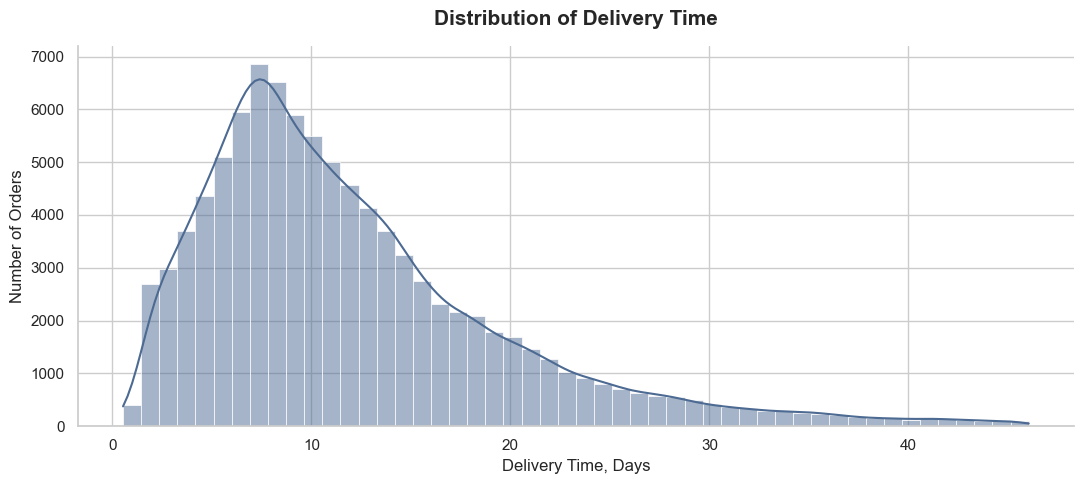

In [32]:
plot_data = delivery_data.loc[
    delivery_data["delivery_time_days"] <= delivery_time_99
].copy()

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(
    data=plot_data,
    x="delivery_time_days",
    bins=50,
    kde=True,
    color="#4C6A92",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_title(
    "Distribution of Delivery Time",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Delivery Time, Days")
ax.set_ylabel("Number of Orders")

sns.despine()
plt.tight_layout()
plt.show()

### Delivery time findings

The distribution of delivery time is right-skewed.

Most delivered orders arrive within approximately 5–15 days, with the highest concentration around 8–10 days. At the same time, a smaller number of orders take substantially longer, which creates a long right tail.

Because of this asymmetry, the median delivery time is more representative of a typical order than the mean. The 90th percentile should also be used to understand how long delivery takes for slower orders.

The values above the 99th percentile were excluded only from the visualization. They should not be removed from the dataset without additional investigation.

## 7. Delivery Delays by State

In [ ]:
query = """
SELECT
    customer_state,
    COUNT(*) AS delivered_orders,

    ROUND(
        AVG(delivery_time_days)::NUMERIC,
        2
    ) AS average_delivery_days,

    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY delivery_time_days
        )::NUMERIC,
        2
    ) AS median_delivery_days,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN is_delayed = TRUE THEN 1
                ELSE 0
            END
        ),
        2
    ) AS delayed_share_percent

FROM analytics.orders_enriched

WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND customer_state IS NOT NULL

GROUP BY customer_state
HAVING COUNT(*) >= 100
ORDER BY delayed_share_percent DESC;
"""

delivery_by_state = pd.read_sql(query, engine)
delivery_by_state

,customer_state,delivered_orders,average_delivery_days,median_delivery_days,delayed_share_percent
0,AL,397,24.54,22.33,23.93
1,MA,717,21.57,19.19,19.67
2,PI,476,19.46,16.29,15.97
3,CE,1279,21.27,18.21,15.32
4,SE,335,21.52,18.01,15.22
5,BA,3256,19.34,16.91,14.04
6,RJ,12350,15.31,12.04,13.47
7,TO,274,17.66,15.87,12.77
8,PA,946,23.77,21.08,12.37
9,ES,1995,15.79,13.64,12.23


In [34]:
top_delayed_states = (
    delivery_by_state
    .nlargest(10, "delayed_share_percent")
    .sort_values("delayed_share_percent", ascending=True)
)

top_delayed_states

,customer_state,delivered_orders,average_delivery_days,median_delivery_days,delayed_share_percent
9,ES,1995,15.79,13.64,12.23
8,PA,946,23.77,21.08,12.37
7,TO,274,17.66,15.87,12.77
6,RJ,12350,15.31,12.04,13.47
5,BA,3256,19.34,16.91,14.04
4,SE,335,21.52,18.01,15.22
3,CE,1279,21.27,18.21,15.32
2,PI,476,19.46,16.29,15.97
1,MA,717,21.57,19.19,19.67
0,AL,397,24.54,22.33,23.93


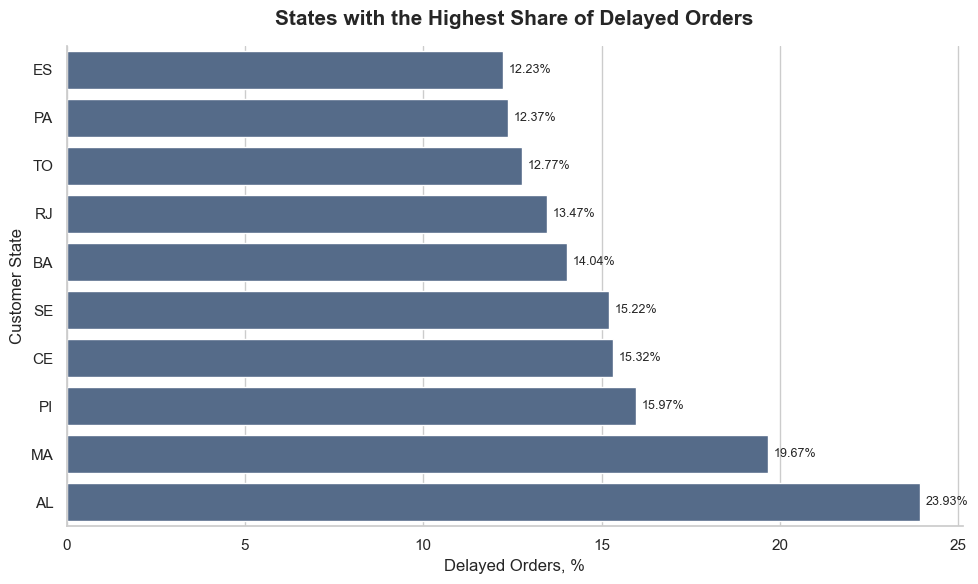

In [35]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_delayed_states,
    x="delayed_share_percent",
    y="customer_state",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "States with the Highest Share of Delayed Orders",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Delayed Orders, %")
ax.set_ylabel("Customer State")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Regional delivery findings

Delivery performance differs noticeably across Brazilian states.

Among states with at least 100 delivered orders, Alagoas (`AL`) has the highest share of delayed orders at approximately 23.9%. Maranhão (`MA`) follows with about 19.7%, while Piauí (`PI`), Ceará (`CE`), and Sergipe (`SE`) also show relatively high delay rates.

The gap between states suggests that delivery problems are not distributed evenly across regions. These differences may be related to distance from sellers, logistics infrastructure, carrier availability, or the geographic concentration of fulfillment operations.

The results should be interpreted together with the number of orders in each state. A high delay rate in a smaller market may have less overall business impact than a moderately elevated delay rate in a high-volume state.

## 8. Reviews and Customer Satisfaction

In [36]:
query = """
SELECT
    review_score,
    COUNT(*) AS reviews_count,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS share_percent
FROM raw.reviews AS r
JOIN analytics.orders_enriched AS o
    ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY review_score
ORDER BY review_score;
"""

review_distribution = pd.read_sql(query, engine)
review_distribution

,review_score,reviews_count,share_percent
0,1,9406,9.76
1,2,2941,3.05
2,3,7961,8.26
3,4,18987,19.70
4,5,57066,59.22


In [37]:
query = """
SELECT
    ROUND(AVG(r.review_score)::NUMERIC, 2) AS average_review_score,

    PERCENTILE_CONT(0.5) WITHIN GROUP (
        ORDER BY r.review_score
    ) AS median_review_score,

    COUNT(*) AS reviews_count

FROM raw.reviews AS r
JOIN analytics.orders_enriched AS o
    ON r.order_id = o.order_id
WHERE o.order_status = 'delivered';
"""

review_summary = pd.read_sql(query, engine)
review_summary

,average_review_score,median_review_score,reviews_count
0,4.16,5.00,96361


In [38]:
query = """
SELECT
    o.is_delayed,
    COUNT(*) AS reviewed_orders,

    ROUND(
        AVG(r.review_score)::NUMERIC,
        2
    ) AS average_review_score,

    ROUND(
        100.0 * AVG(
            CASE
                WHEN r.review_score <= 2 THEN 1
                ELSE 0
            END
        ),
        2
    ) AS low_score_share_percent

FROM raw.reviews AS r
JOIN analytics.orders_enriched AS o
    ON r.order_id = o.order_id

WHERE o.order_status = 'delivered'
  AND o.is_delayed IS NOT NULL

GROUP BY o.is_delayed
ORDER BY o.is_delayed;
"""

reviews_by_delay = pd.read_sql(query, engine)
reviews_by_delay

,is_delayed,reviewed_orders,average_review_score,low_score_share_percent
0,False,88653,4.29,9.23
1,True,7700,2.57,54.03


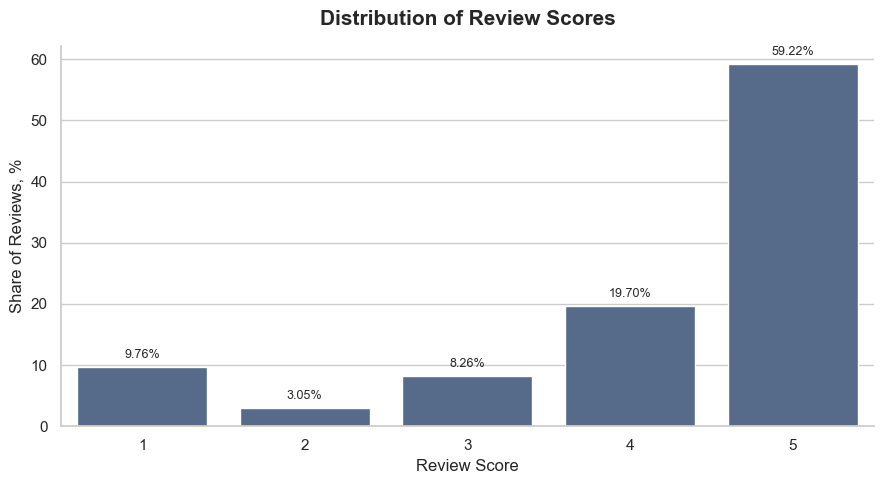

In [39]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=review_distribution,
    x="review_score",
    y="share_percent",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Distribution of Review Scores",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Review Score")
ax.set_ylabel("Share of Reviews, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Review score findings

Customer satisfaction is generally high: approximately 59% of delivered orders received the maximum score of 5, while another 19.7% received a score of 4.

At the same time, low ratings are not negligible. Scores of 1 and 2 together account for approximately 12.8% of reviews, which indicates that a meaningful minority of customers experienced serious problems.

The distribution is strongly concentrated at the highest score, so the average review score alone may hide dissatisfied customers. For further analysis, it is useful to track both the average score and the share of low ratings.

## 9. Impact of Delivery Delays on Reviews

In [40]:
reviews_by_delay_plot = reviews_by_delay.copy()

reviews_by_delay_plot["delivery_status"] = (
    reviews_by_delay_plot["is_delayed"]
    .map({
        False: "On Time",
        True: "Delayed",
    })
)

reviews_by_delay_plot

,is_delayed,reviewed_orders,average_review_score,low_score_share_percent,delivery_status
0,False,88653,4.29,9.23,On Time
1,True,7700,2.57,54.03,Delayed


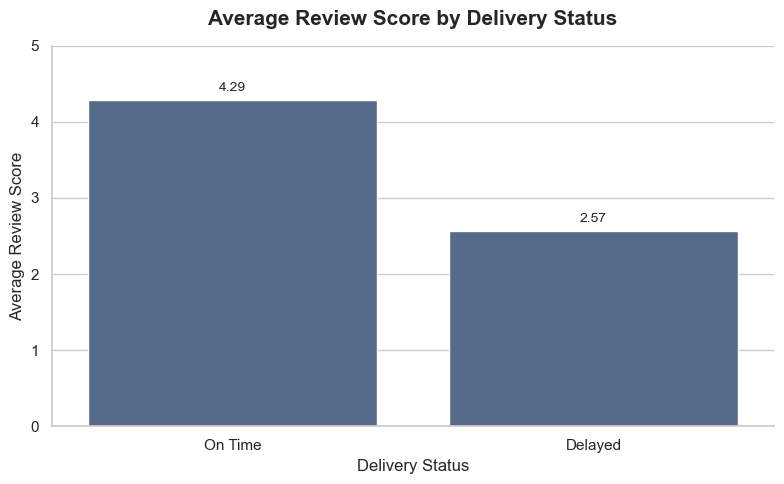

In [41]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=reviews_by_delay_plot,
    x="delivery_status",
    y="average_review_score",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Average Review Score by Delivery Status",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Delivery Status")
ax.set_ylabel("Average Review Score")
ax.set_ylim(0, 5)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4,
        fontsize=10,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Impact of delivery delays on customer satisfaction

Delivery delays are strongly associated with lower customer satisfaction.

Orders delivered on time have an average review score of 4.29, while delayed orders have an average score of only 2.57. The difference of 1.72 points is substantial on a five-point scale.

This suggests that delivery performance is one of the key factors influencing customer experience. However, the result shows an association rather than proving that delays are the only cause of low ratings. Product quality, seller performance, and order value may also affect review scores.

## 10. Product Category Performance

In [42]:
query = """
SELECT
    i.product_category_name_english,
    COUNT(*) AS order_items_count,
    COUNT(DISTINCT i.order_id) AS orders_count,

    ROUND(
        SUM(i.price)::NUMERIC,
        2
    ) AS products_value,

    ROUND(
        AVG(i.price)::NUMERIC,
        2
    ) AS average_item_price

FROM analytics.order_items_enriched AS i
JOIN analytics.orders_enriched AS o
    ON i.order_id = o.order_id

WHERE o.order_status = 'delivered'

GROUP BY i.product_category_name_english
ORDER BY products_value DESC;
"""

category_performance = pd.read_sql(query, engine)
category_performance.head(15)

,product_category_name_english,order_items_count,orders_count,products_value,average_item_price
0,health_beauty,9465,8647,"1,233,131.72",130.28
1,watches_gifts,5859,5495,"1,166,176.98",199.04
2,bed_bath_table,10953,9272,"1,023,434.76",93.44
3,sports_leisure,8431,7530,"954,852.55",113.25
4,computers_accessories,7644,6530,"888,724.61",116.26
5,furniture_decor,8160,6307,"711,927.69",87.25
6,housewares,6795,5743,"615,628.69",90.60
7,cool_stuff,3718,3559,"610,204.10",164.12
8,auto,4140,3810,"578,966.65",139.85
9,toys,4030,3804,"471,286.48",116.94


In [43]:
top_categories = (
    category_performance
    .head(15)
    .sort_values("products_value", ascending=True)
)

top_categories

,product_category_name_english,order_items_count,orders_count,products_value,average_item_price
14,office_furniture,1668,1254,"268,154.31",160.76
13,telephony,4430,4093,"309,860.23",69.95
12,perfumery,3340,3086,"390,144.65",116.81
11,baby,2982,2809,"400,421.84",134.28
10,garden_tools,4268,3448,"470,495.28",110.24
9,toys,4030,3804,"471,286.48",116.94
8,auto,4140,3810,"578,966.65",139.85
7,cool_stuff,3718,3559,"610,204.10",164.12
6,housewares,6795,5743,"615,628.69",90.60
5,furniture_decor,8160,6307,"711,927.69",87.25


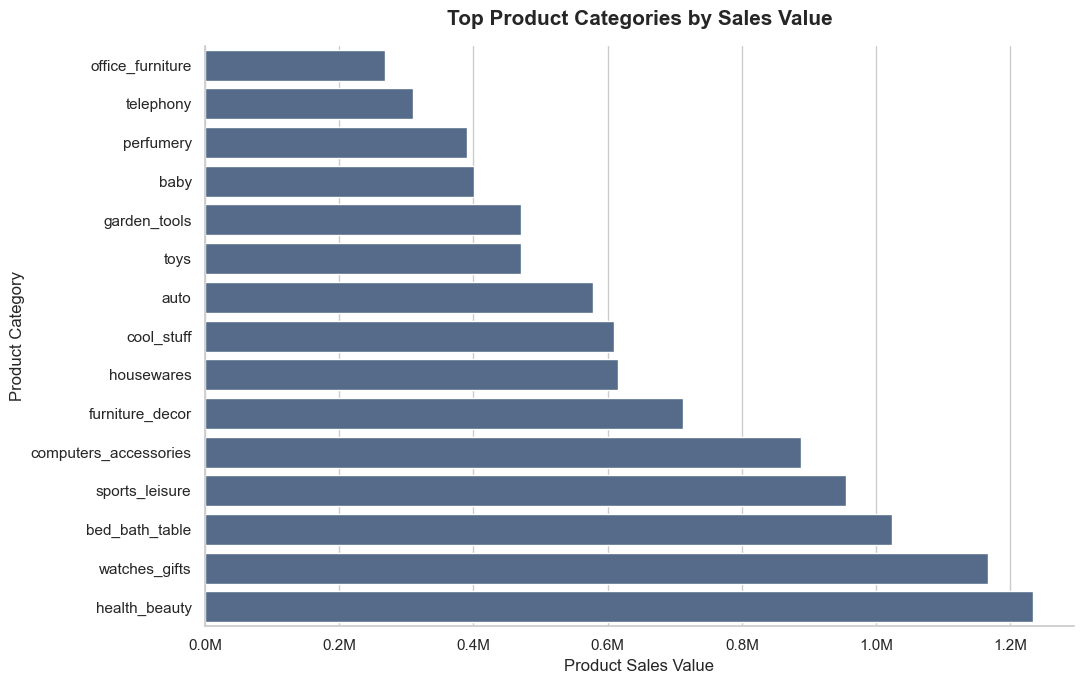

In [44]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_categories,
    x="products_value",
    y="product_category_name_english",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Top Product Categories by Sales Value",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Product Sales Value")
ax.set_ylabel("Product Category")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value / 1_000_000:.1f}M"
    )
)

sns.despine()
plt.tight_layout()
plt.show()

### Product category findings

Sales value is concentrated in a relatively small group of product categories.

`health_beauty` has the highest total product sales value, followed by `watches_gifts`, `bed_bath_table`, `sports_leisure`, and `computers_accessories`.

The ranking reflects total sales value, not necessarily the number of orders. A category may appear near the top because it has many purchases, a high average item price, or both.

This concentration suggests that category-level analysis should consider several metrics together: total sales value, number of orders, number of items sold, and average item price.

## 11. Geographic Distribution of Orders

In [45]:
query = """
SELECT
    customer_state,
    COUNT(*) AS orders_count,

    ROUND(
        SUM(order_items_value)::NUMERIC,
        2
    ) AS total_order_value,

    ROUND(
        AVG(order_items_value)::NUMERIC,
        2
    ) AS average_order_value

FROM analytics.order_metrics

WHERE order_status = 'delivered'
  AND customer_state IS NOT NULL
  AND order_items_value IS NOT NULL

GROUP BY customer_state
ORDER BY orders_count DESC;
"""

orders_by_state = pd.read_sql(query, engine)
orders_by_state

,customer_state,orders_count,total_order_value,average_order_value
0,SP,40501,"5,769,703.15",142.46
1,RJ,12350,"2,055,401.57",166.43
2,MG,11354,"1,818,891.67",160.20
3,RS,5345,"861,472.79",161.17
4,PR,4923,"781,708.80",158.79
5,SC,3546,"595,127.78",167.83
6,BA,3256,"591,137.81",181.55
7,DF,2080,"346,123.35",166.41
8,ES,1995,"317,657.93",159.23
9,GO,1957,"334,212.35",170.78


In [46]:
orders_by_state["orders_share_percent"] = (
    orders_by_state["orders_count"]
    / orders_by_state["orders_count"].sum()
    * 100
)

orders_by_state.head(10)

,customer_state,orders_count,total_order_value,average_order_value,orders_share_percent
0,SP,40501,"5,769,703.15",142.46,41.98
1,RJ,12350,"2,055,401.57",166.43,12.80
2,MG,11354,"1,818,891.67",160.20,11.77
3,RS,5345,"861,472.79",161.17,5.54
4,PR,4923,"781,708.80",158.79,5.10
5,SC,3546,"595,127.78",167.83,3.68
6,BA,3256,"591,137.81",181.55,3.37
7,DF,2080,"346,123.35",166.41,2.16
8,ES,1995,"317,657.93",159.23,2.07
9,GO,1957,"334,212.35",170.78,2.03


In [47]:
top_order_states = (
    orders_by_state
    .nlargest(10, "orders_count")
    .sort_values("orders_count", ascending=True)
)

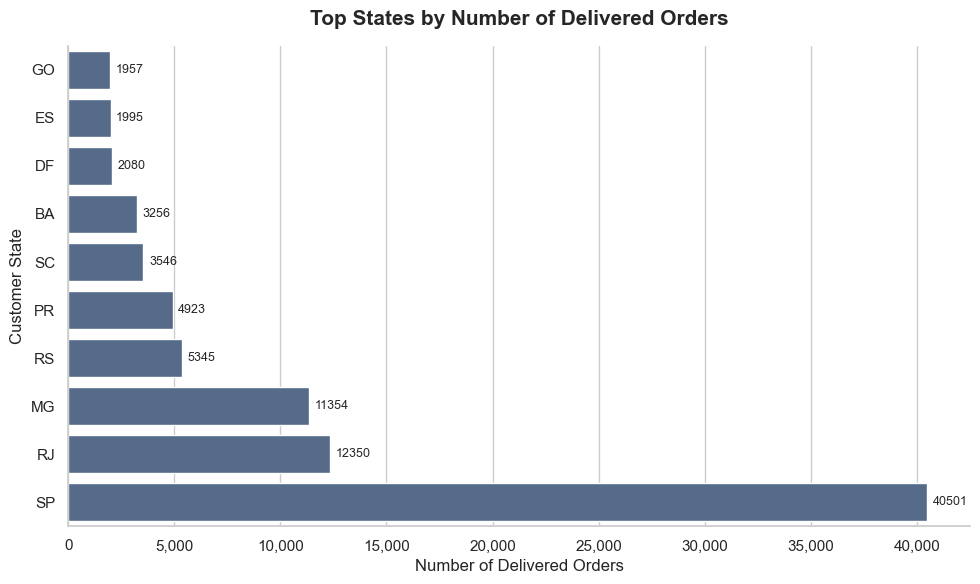

In [48]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_order_states,
    x="orders_count",
    y="customer_state",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Top States by Number of Delivered Orders",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Number of Delivered Orders")
ax.set_ylabel("Customer State")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{int(value):,}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Geographic distribution findings

Delivered orders are highly concentrated geographically.

São Paulo (`SP`) accounts for 40,501 delivered orders, far more than any other state. Rio de Janeiro (`RJ`) and Minas Gerais (`MG`) follow, but with substantially lower order volumes.

This concentration indicates that the platform’s customer base is dominated by the Southeast region. As a result, overall metrics may be strongly influenced by the behavior and logistics performance of a relatively small number of high-volume states.

Geographic concentration should be considered when interpreting delivery performance, customer satisfaction, and sales results, since national averages may hide substantial regional differences.

## 12. Initial Conclusions and Hypotheses

### Key findings

1. The dataset covers a growing e-commerce business, with a clear increase in monthly order volume from early 2017 and relatively stable activity during most of 2018.

2. Delivered orders represent approximately 97% of all orders, so the dataset is primarily composed of completed transactions.

3. Missing values are generally limited and are mostly explained by incomplete order lifecycles rather than by broad data-quality problems.

4. Order values and delivery times are both right-skewed. Therefore, medians and percentiles should be used together with averages.

5. Delivery delays vary substantially across states, suggesting regional differences in logistics performance.

6. Customer satisfaction is generally high, but delivery delays are strongly associated with lower review scores.

7. Sales are concentrated both by product category and geography. A relatively small group of categories and states contributes a large share of activity.

### Hypotheses for further analysis

- Customers who experience delivery delays are less likely to make a repeat purchase.
- Some product categories may have systematically longer delivery times or lower review scores.
- High-value orders may be associated with longer delivery times or a higher risk of delays.
- Regional delivery differences may be explained by distance between customers and sellers.
- Customer retention may differ across acquisition cohorts, regions, and product categories.

In [49]:
engine.dispose()